# Step 5: Data Visualization & Merging DataFrames

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Age': [24, 29, 32, 27, 22, 38, 31, 25, 30, 26],
    'City': ['New York', 'London', 'Paris', 'New York', 'Berlin', 'London', 'Paris', 'New York', 'Berlin', 'London'],
    'Score': [85, 92, 78, 65, 95, 70, 88, 75, 90, 82],
    'Study_Hours': [5, 7, 4, 3, 8, 6, 5, 4, 7, 6],
    'Gender': ['F', 'M', 'M', 'M', 'F', 'M', 'F', 'F', 'M', 'F']
}
df = pd.DataFrame(data)
pd.set_option('display.width', 1000)
## introduce a hidden score for demo
df.loc[3, 'Score'] = np.nan
df['Score'].fillna(df['Score'].mean(), inplace=True)
print ("-----Data frame ----- \n",df )
print("----- Basic data visualisation using matplot and seaborn -----")


-----Data frame ----- 
    Student_ID     Name  Age      City      Score  Study_Hours Gender
0           1    Alice   24  New York  85.000000            5      F
1           2      Bob   29    London  92.000000            7      M
2           3  Charlie   32     Paris  78.000000            4      M
3           4    David   27  New York  83.888889            3      M
4           5      Eve   22    Berlin  95.000000            8      F
5           6    Frank   38    London  70.000000            6      M
6           7    Grace   31     Paris  88.000000            5      F
7           8    Heidi   25  New York  75.000000            4      F
8           9     Ivan   30    Berlin  90.000000            7      M
9          10     Judy   26    London  82.000000            6      F
----- Basic data visualisation using matplot and seaborn -----


/var/folders/1l/ynphxd1j4wsdzdtqf5z1jvw80000gn/T/ipykernel_10413/3858947449.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Score'].fillna(df['Score'].mean(), inplace=True)


In [3]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

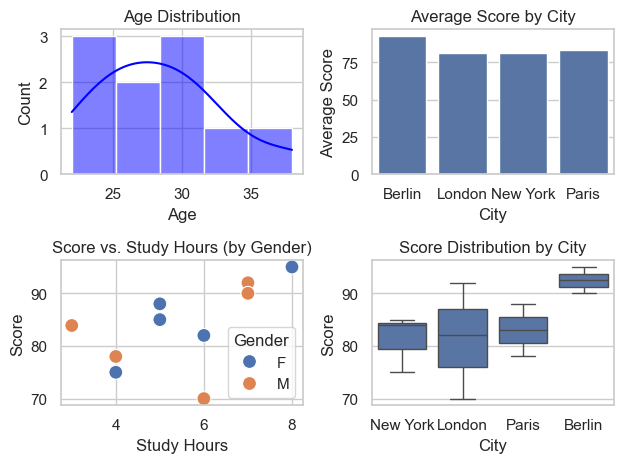

In [4]:



# Histogram for Age distrubution
plt.subplot(2, 2, 1) # rows, column, plot_number
sns.histplot(df['Age'], bins=5, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
# Bar plot for average score per City
plt.subplot(2, 2, 2)
sns.barplot(x='City', y='Score', data=df.groupby('City')['Score'].mean().reset_index())
plt.title('Average Score by City')
plt.xlabel('City')
plt.ylabel('Average Score')
# Scatter plot for Score vs. Study_Hours
plt.subplot(2, 2, 3)
sns.scatterplot(x='Study_Hours', y='Score', hue='Gender', data=df, s=100) # s=size of points, hue=color by Gender
plt.title('Score vs. Study Hours (by Gender)')
plt.xlabel('Study Hours')
plt.ylabel('Score')
# Box plot for Score distribution by City
plt.subplot(2, 2, 4)
sns.boxplot(x='City', y='Score', data=df)
plt.title('Score Distribution by City')
plt.xlabel('City')
plt.ylabel('Score')

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show() # Display the plots



In [5]:
print("\n--- 5.2: Merging DataFrames (like SQL JOINS) ---")

# Let's create another DataFrame, perhaps containing more details about cities
city_data = pd.DataFrame({
    'City': ['New York', 'London', 'Paris', 'Berlin'],
    'Country': ['USA', 'UK', 'France', 'Germany'],
    'Population_Millions': [8.4, 8.9, 2.1, 3.7]
})
print("\nCity Data DataFrame:\n", city_data)

# Merge df with city_data on the 'City' column
# This is like an INNER JOIN in SQL: only rows where 'City' matches in BOTH DataFrames are kept.
merged_df = pd.merge(df, city_data, on='City', how='inner')


print("\nDataFrame after INNER MERGE with City Data:\n", merged_df)

# Example of a LEFT JOIN (keep all rows from 'df', add city_data where matches)
# Let's add a city not in city_data to df to see how left join behaves
df_left_join_test = df.copy()
df_left_join_test.loc[len(df_left_join_test)] = [11, 'Zoe', 23, 'Rome', 80, 5, 'F'] # Rome is not in city_data



--- 5.2: Merging DataFrames (like SQL JOINS) ---

City Data DataFrame:
        City  Country  Population_Millions
0  New York      USA                  8.4
1    London       UK                  8.9
2     Paris   France                  2.1
3    Berlin  Germany                  3.7

DataFrame after INNER MERGE with City Data:
    Student_ID     Name  Age      City      Score  Study_Hours Gender  Country  Population_Millions
0           1    Alice   24  New York  85.000000            5      F      USA                  8.4
1           2      Bob   29    London  92.000000            7      M       UK                  8.9
2           3  Charlie   32     Paris  78.000000            4      M   France                  2.1
3           4    David   27  New York  83.888889            3      M      USA                  8.4
4           5      Eve   22    Berlin  95.000000            8      F  Germany                  3.7
5           6    Frank   38    London  70.000000            6      M       UK

In [26]:

print(len(df_left_join_test))

11


In [28]:

left_merged_df = pd.merge(df_left_join_test, city_data, on='City', how='left')
print("\nDataFrame after LEFT MERGE (notice Rome has NaNs for new columns):\n", left_merged_df)



DataFrame after LEFT MERGE (notice Rome has NaNs for new columns):
     Student_ID     Name  Age      City      Score  Study_Hours Gender  \
0            1    Alice   24  New York  85.000000            5      F   
1            2      Bob   29    London  92.000000            7      M   
2            3  Charlie   32     Paris  78.000000            4      M   
3            4    David   27  New York  83.888889            3      M   
4            5      Eve   22    Berlin  95.000000            8      F   
5            6    Frank   38    London  70.000000            6      M   
6            7    Grace   31     Paris  88.000000            5      F   
7            8    Heidi   25  New York  75.000000            4      F   
8            9     Ivan   30    Berlin  90.000000            7      M   
9           10     Judy   26    London  82.000000            6      F   
10          11      Zoe   23      Rome  80.000000            5      F   

    Country  Population_Millions  
0       USA        